scoreable rows: 118783
Ranking definition: pooled GAT RMSE across all scoreable horizons


,rank,fipsCode,countyName,stateAbbr,n_rows,base_rmse,gat_rmse,gat_minus_base_rmse,gat_sse_contribution_pct
0,1,18111,Newton County,IN,497,0.003512,0.111770,0.108258,34.374539
1,2,42053,Forest County,PA,497,0.063804,0.064735,0.000931,11.530980
2,3,54015,Clay County,WV,497,0.053605,0.054904,0.001299,8.294557
3,4,54013,Calhoun County,WV,497,0.046995,0.043670,-0.003324,5.247585
4,5,39115,Morgan County,OH,497,0.033946,0.033960,0.000013,3.173332
5,6,39117,Morrow County,OH,497,0.033075,0.031820,-0.001255,2.786105
6,7,18013,Brown County,IN,497,0.028305,0.027225,-0.001081,2.039447
7,8,39119,Muskingum County,OH,497,0.025858,0.024234,-0.001623,1.616022
8,9,18121,Parke County,IN,497,0.022830,0.022787,-0.000043,1.428818
9,10,54007,Braxton County,WV,497,0.025779,0.022570,-0.003210,1.401633


C:\Users\wanji\AppData\Local\Temp\ipykernel_23980\984572811.py:83: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
d:\app\anacnda1\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


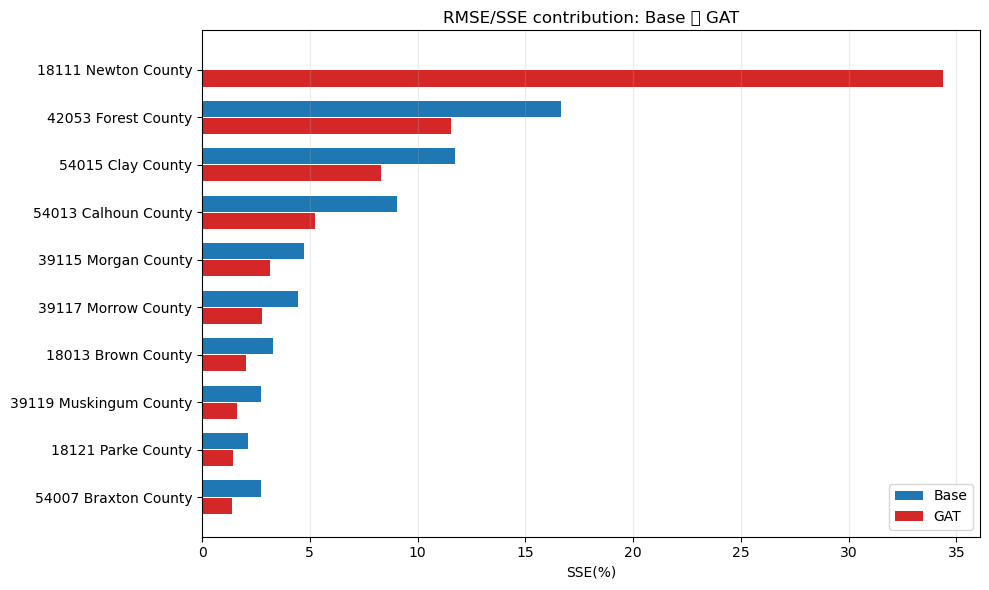

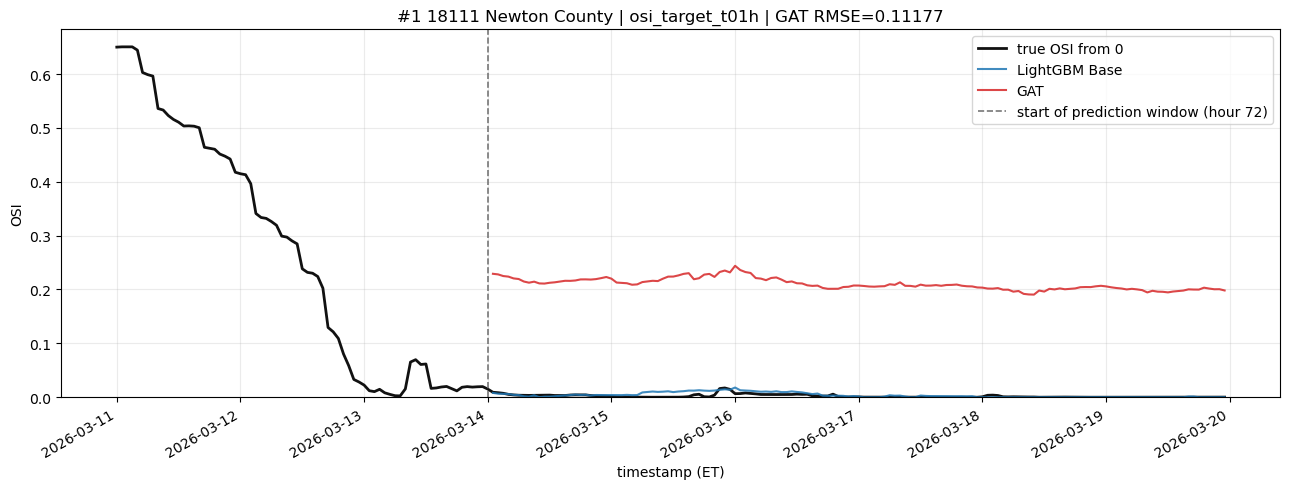

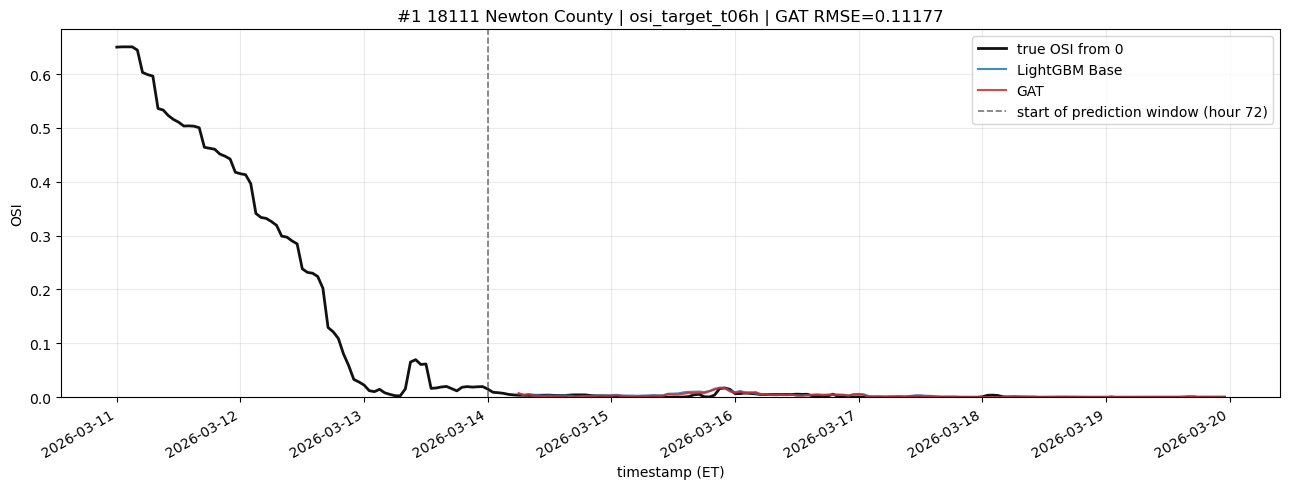

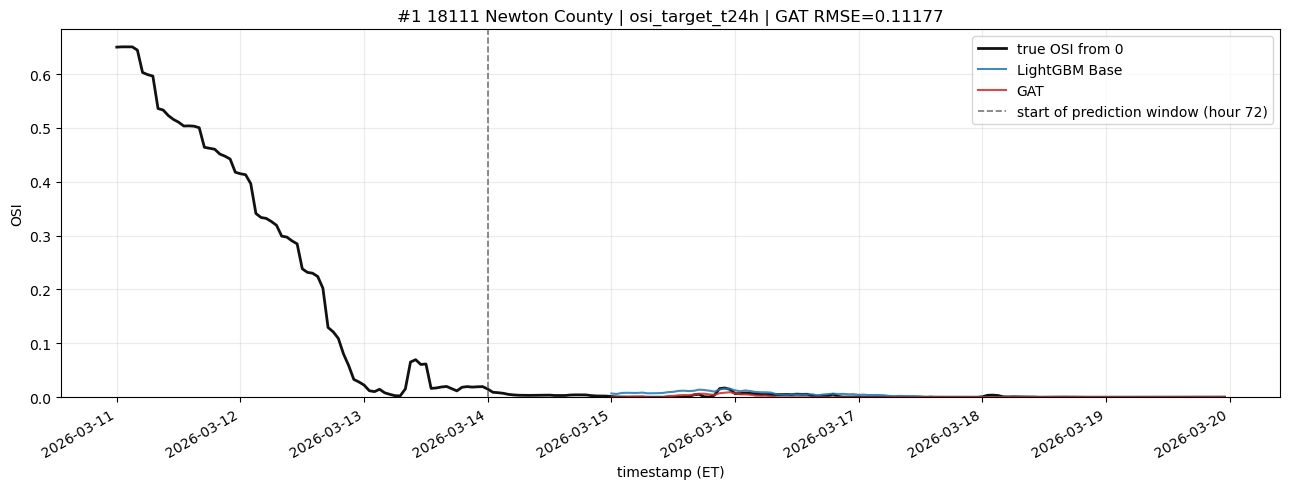

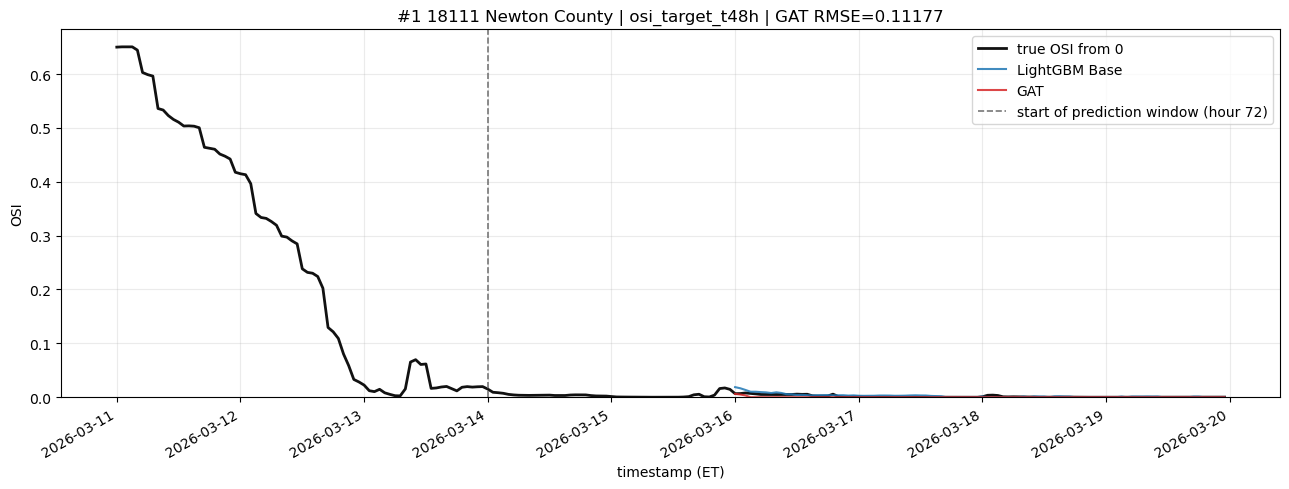

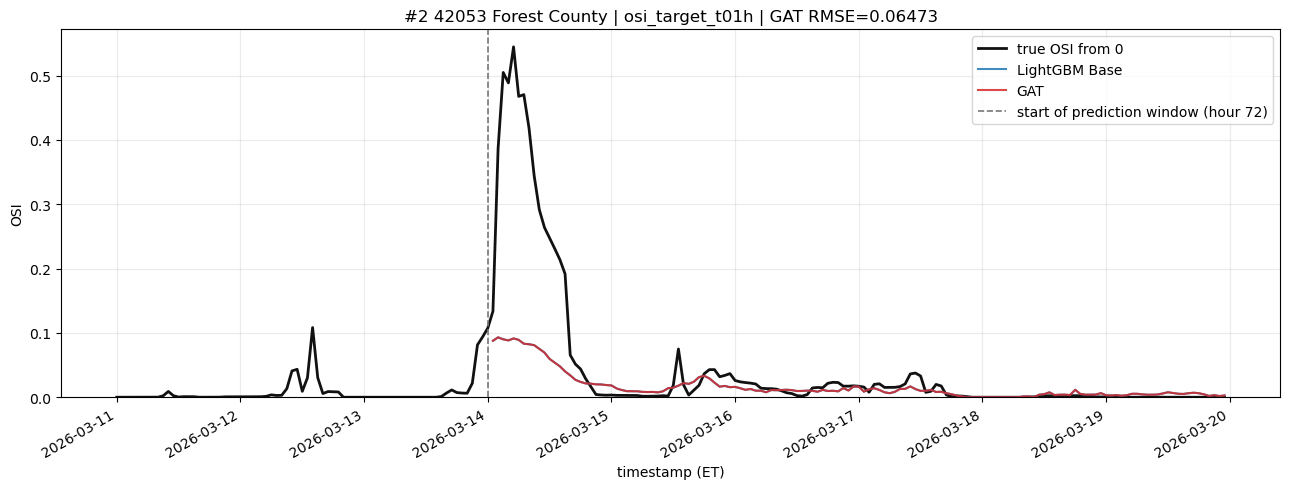

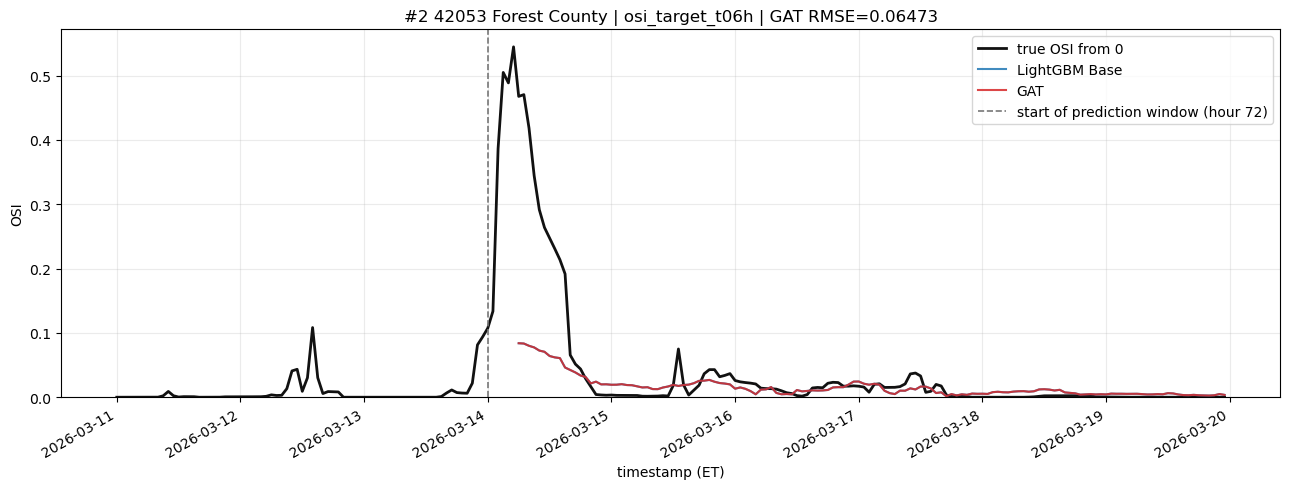

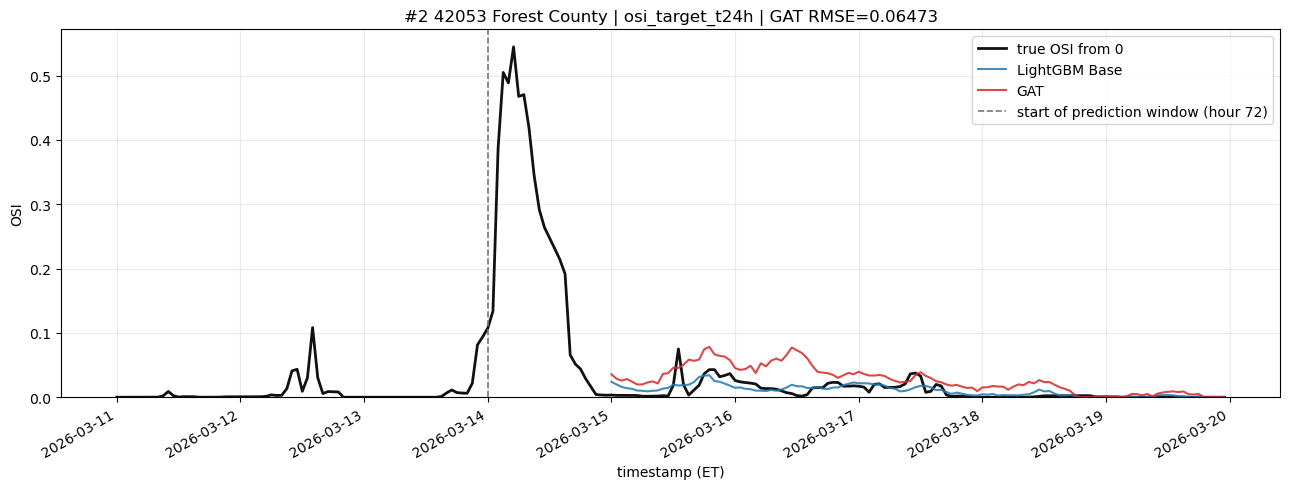

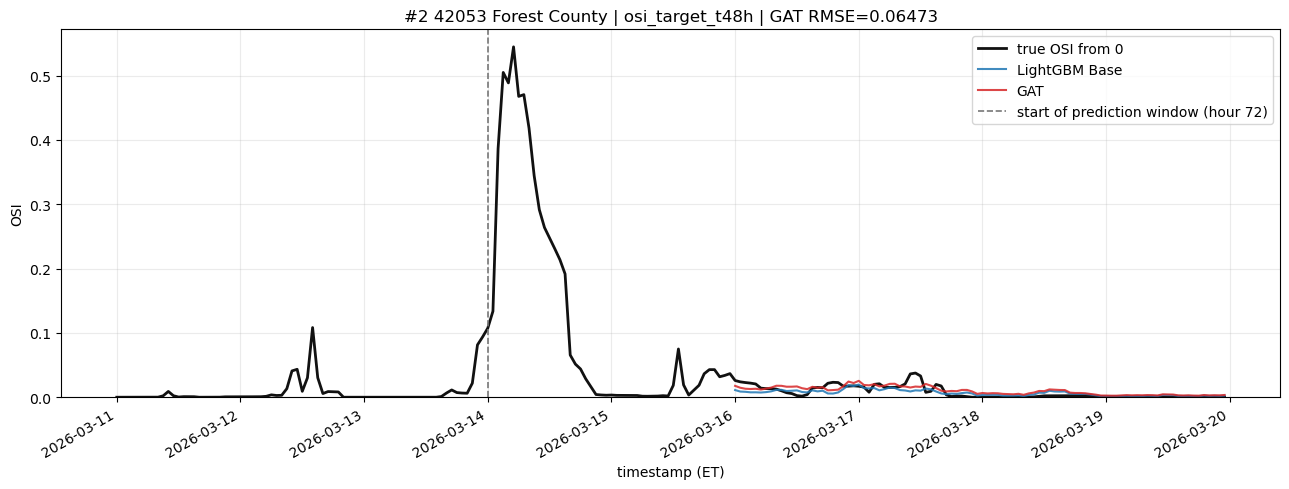

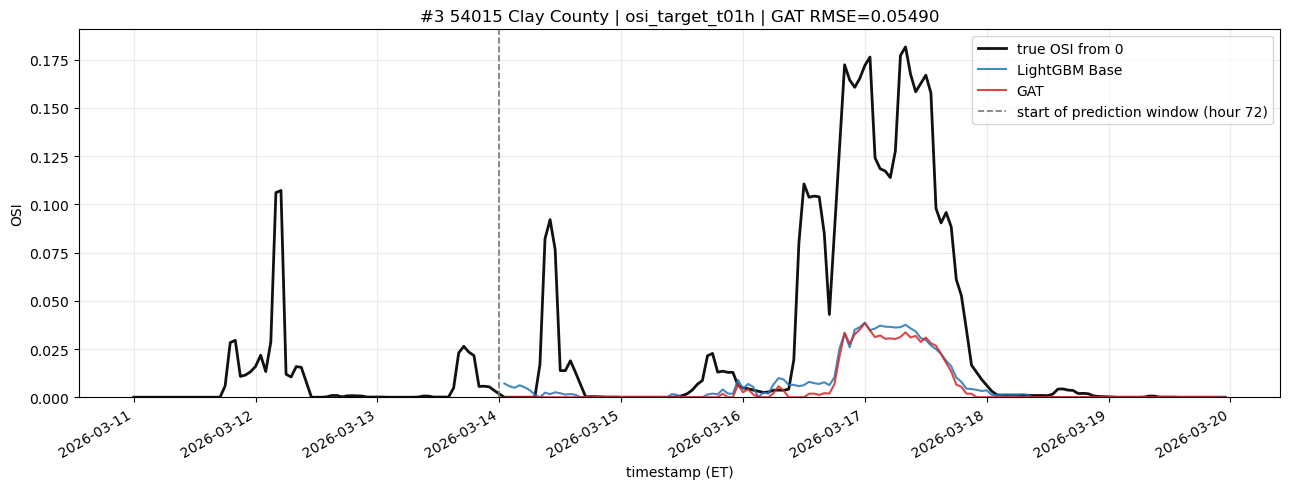

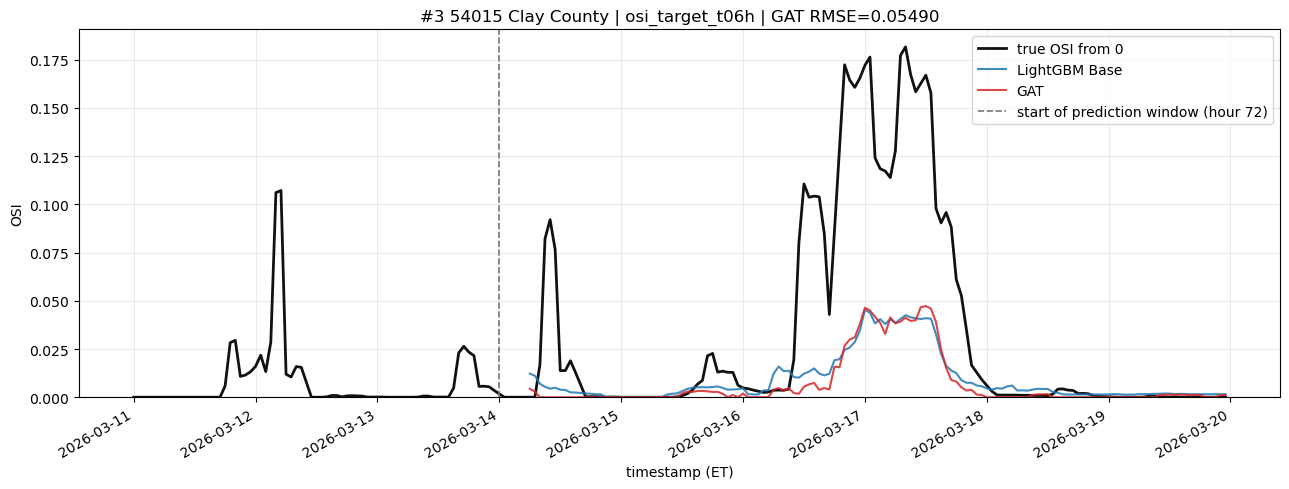

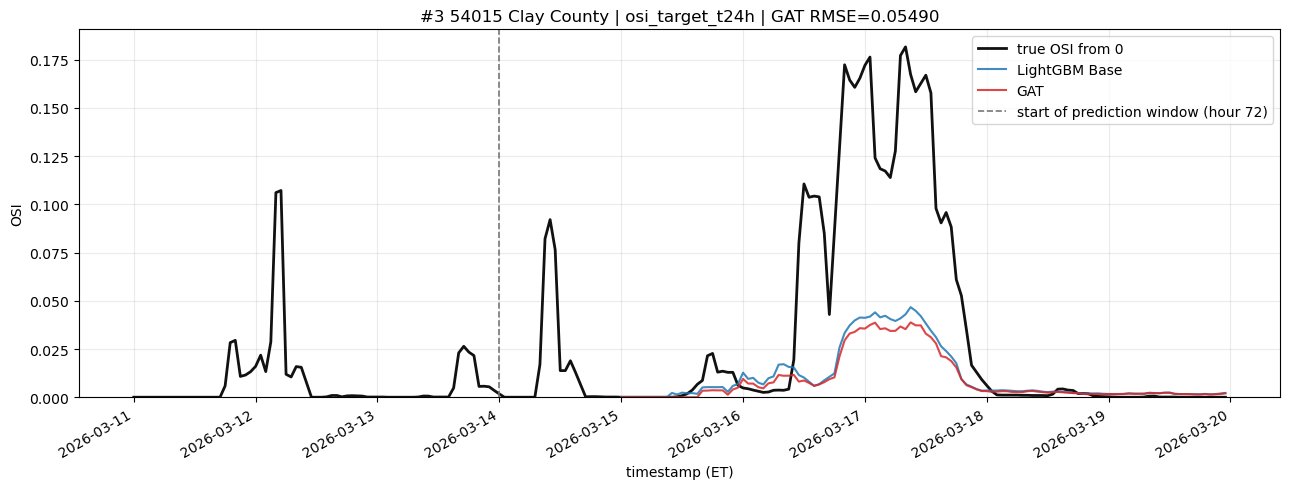

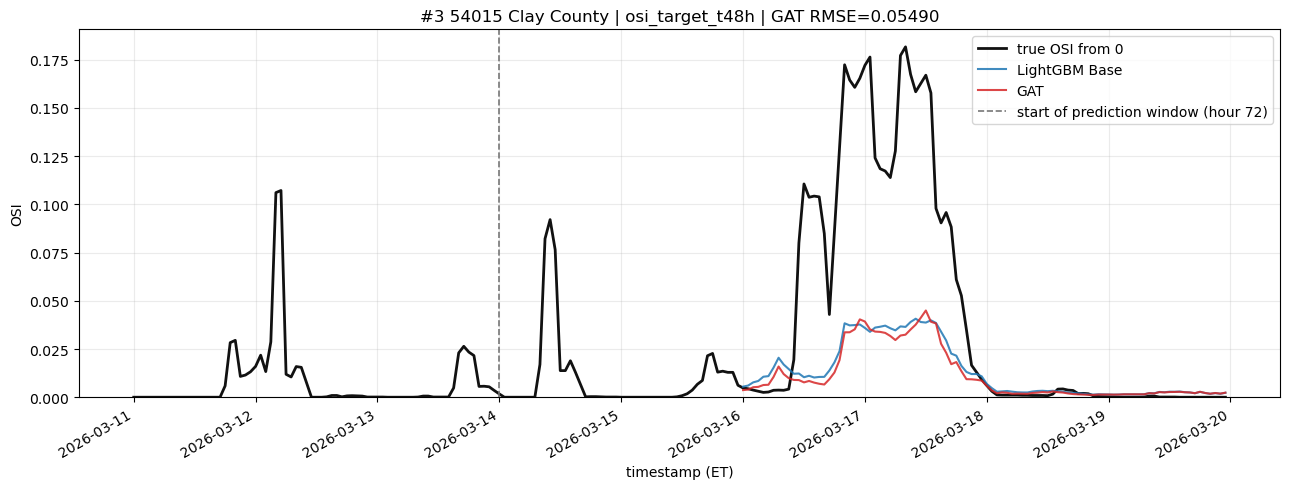

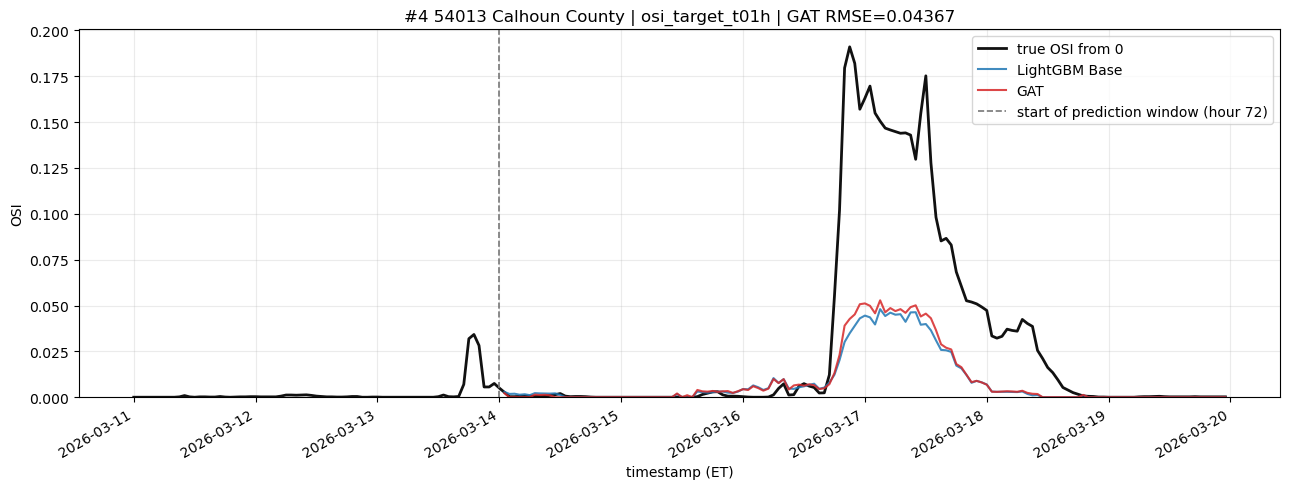

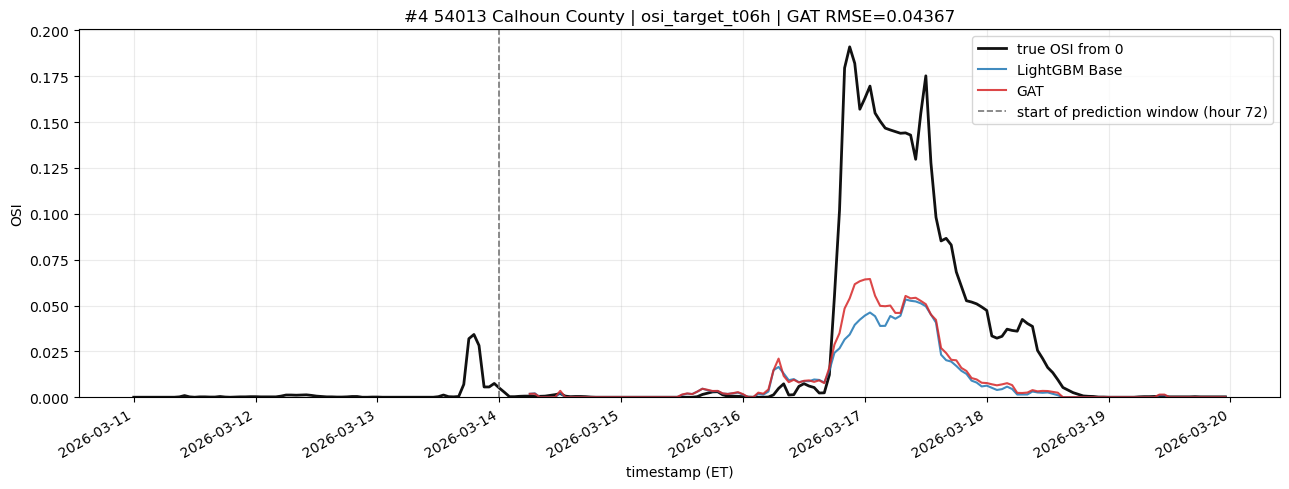

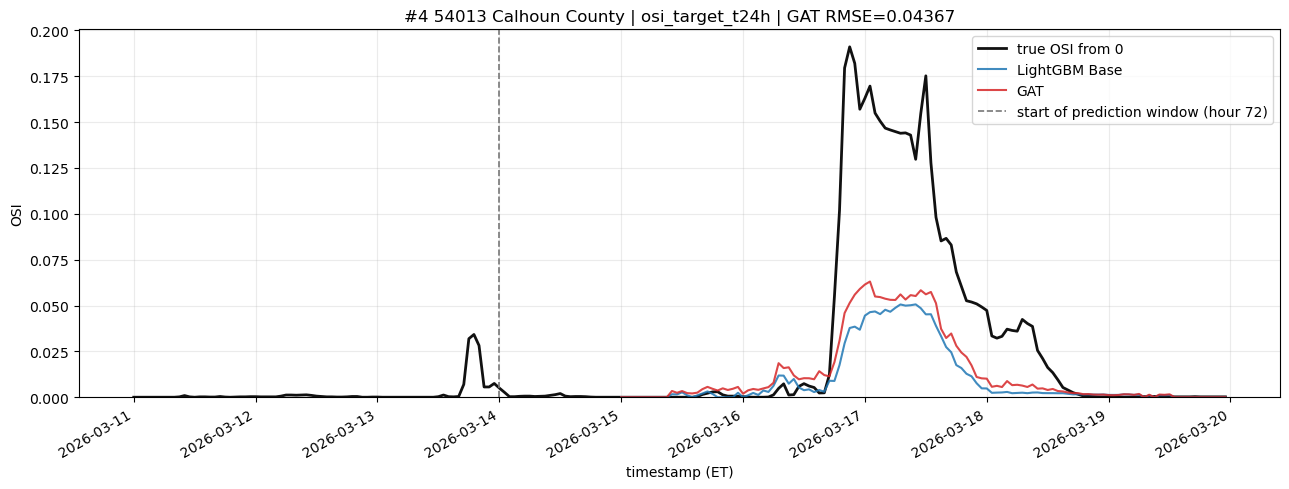

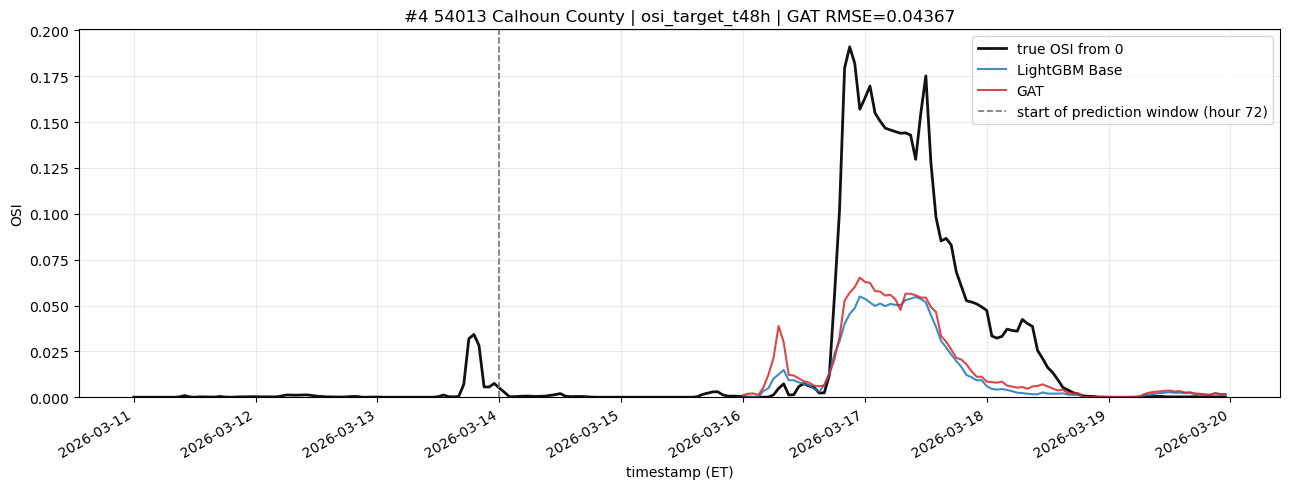

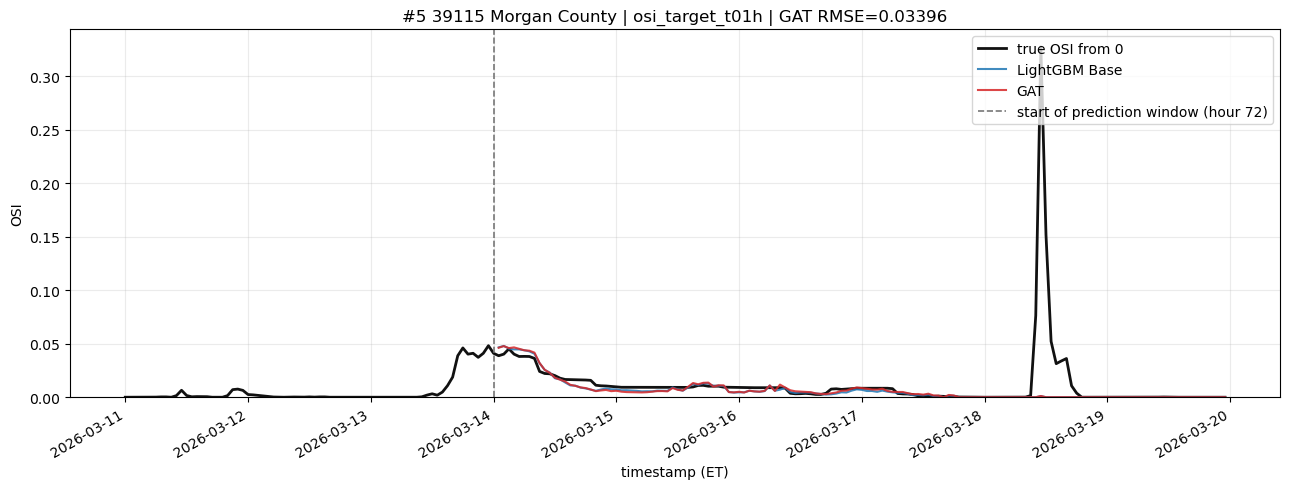

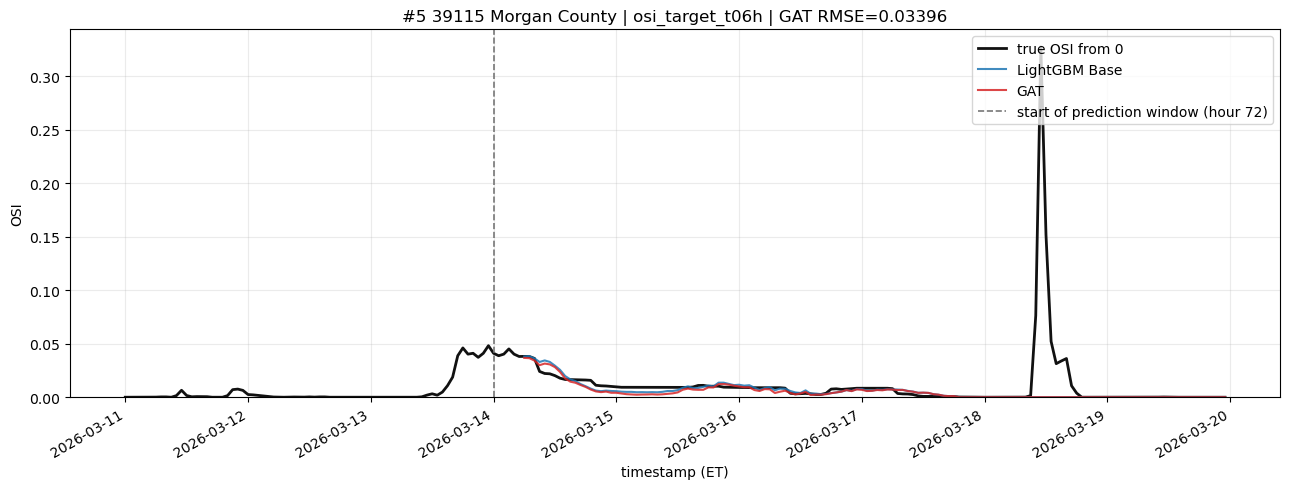

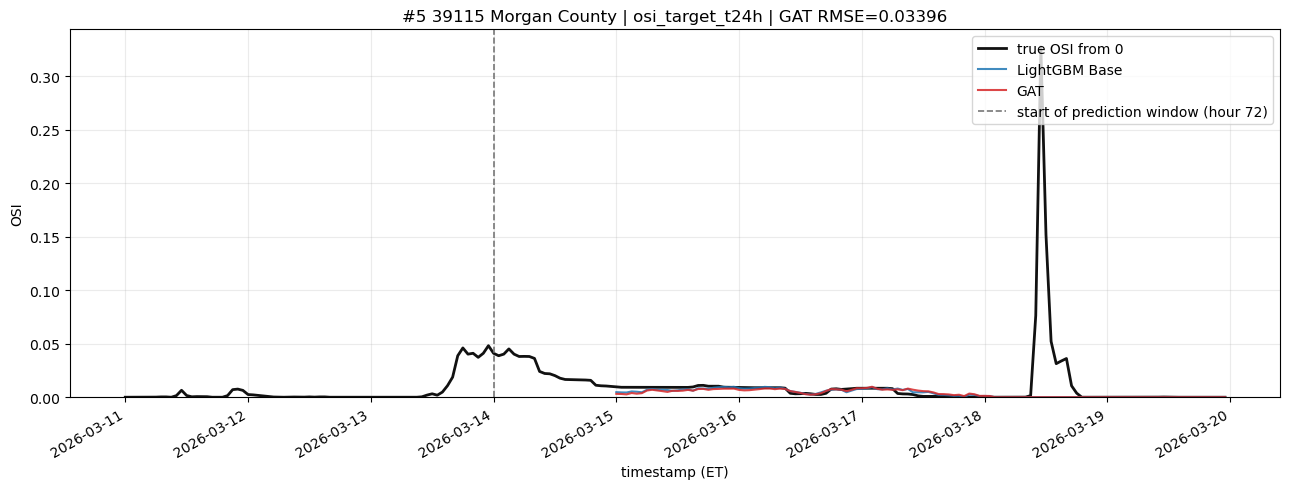

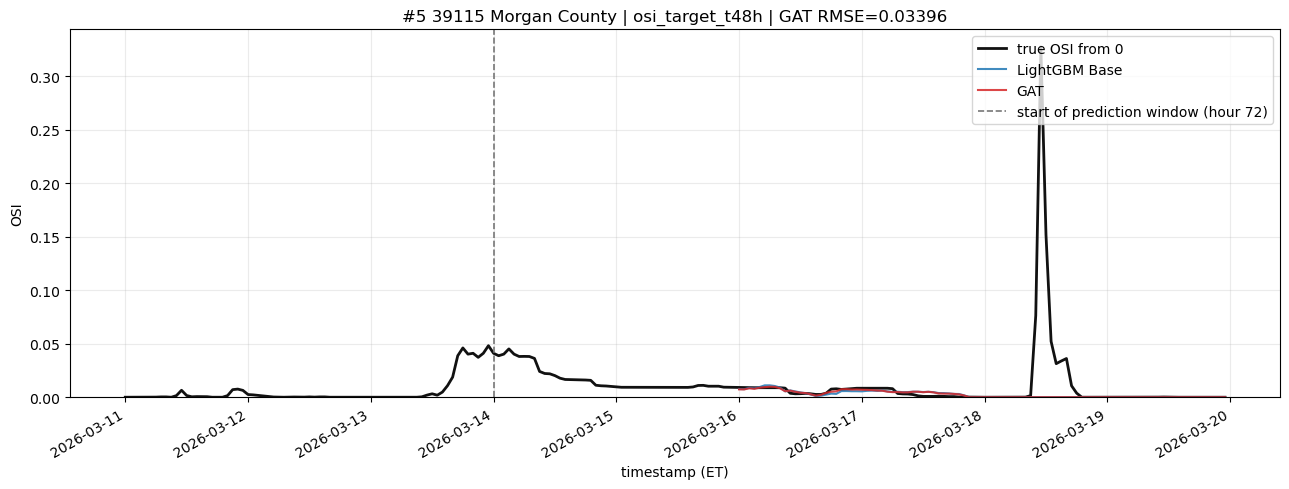

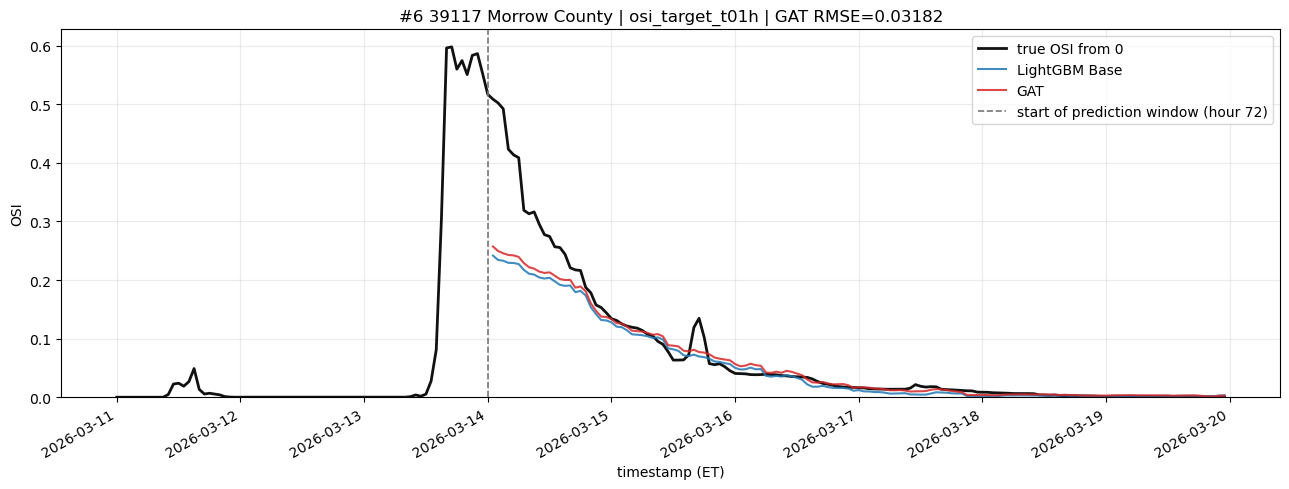

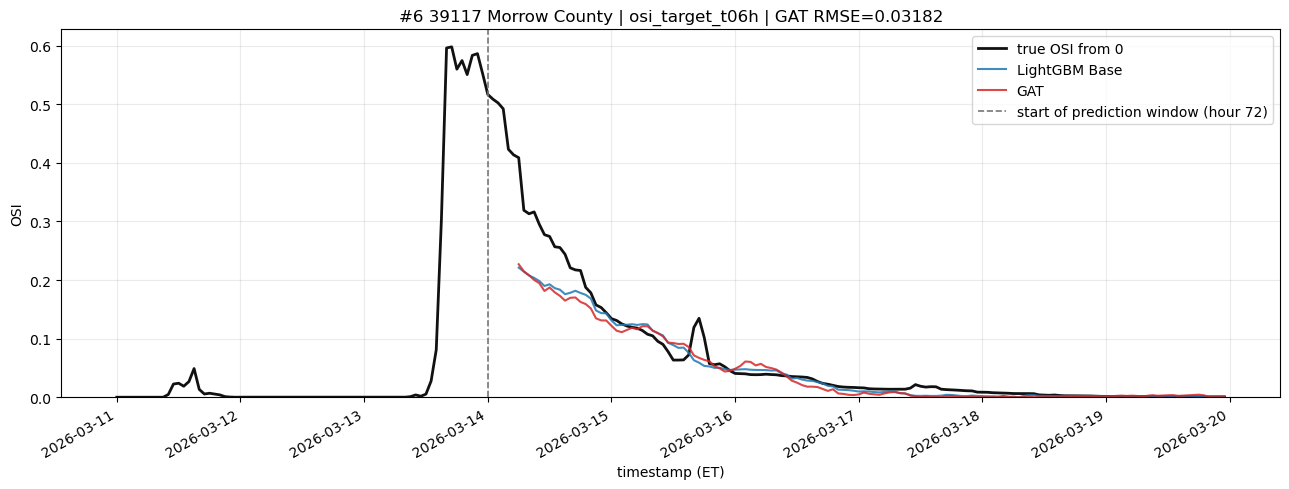

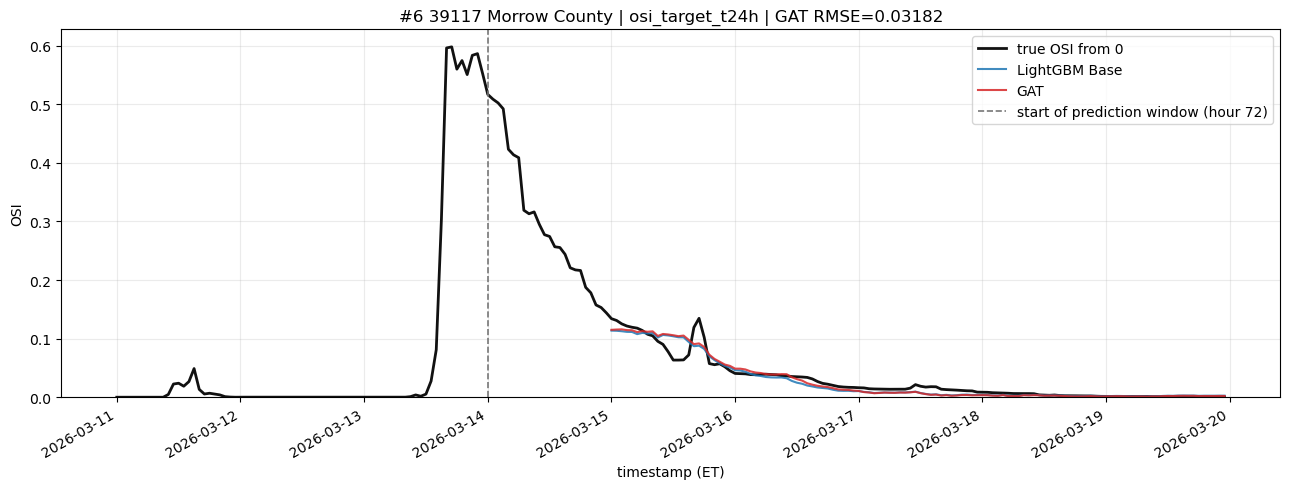

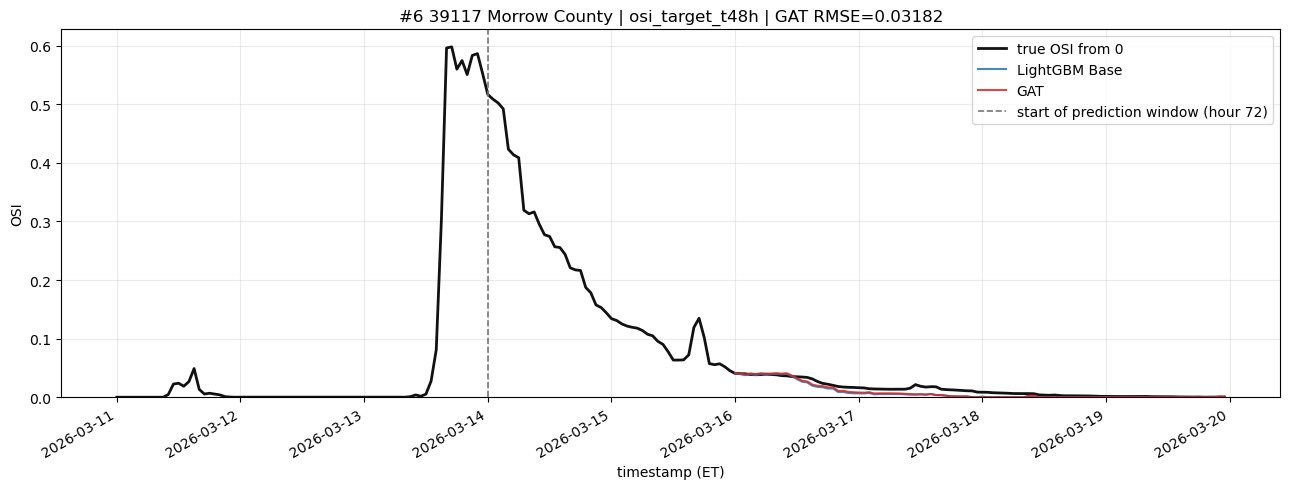

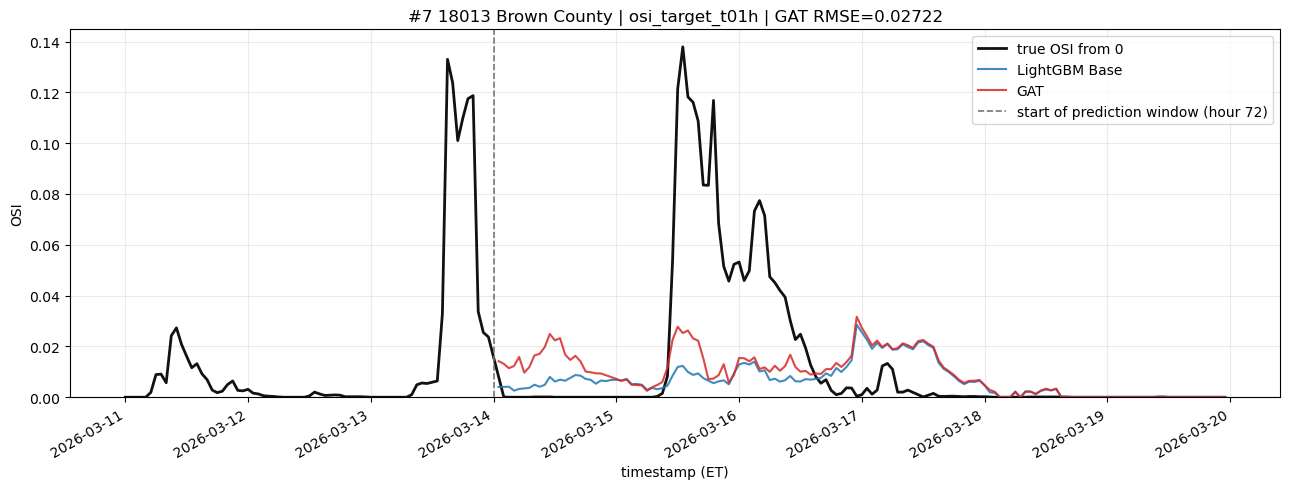

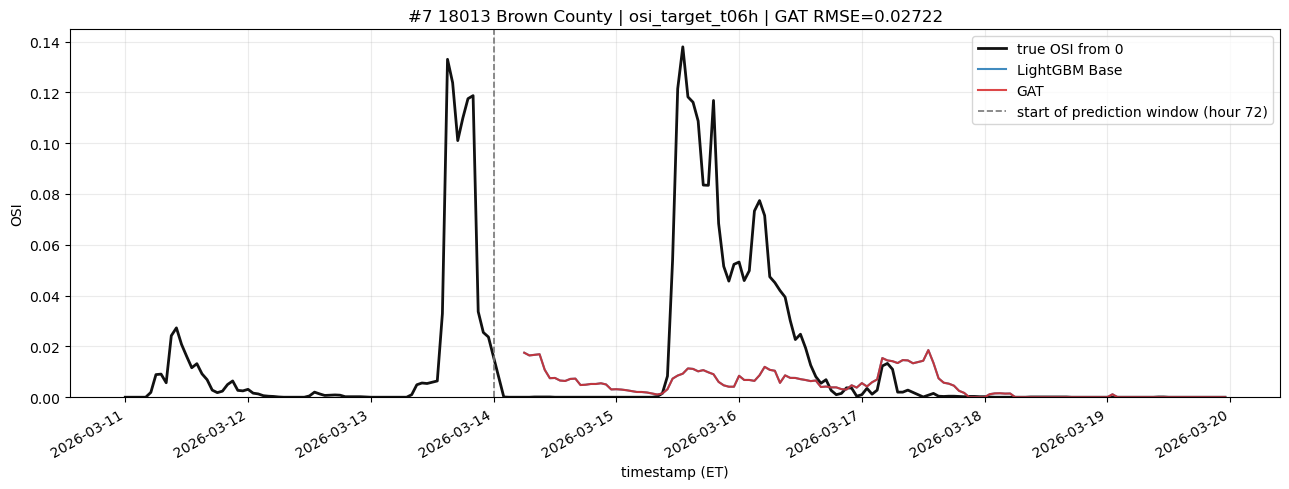

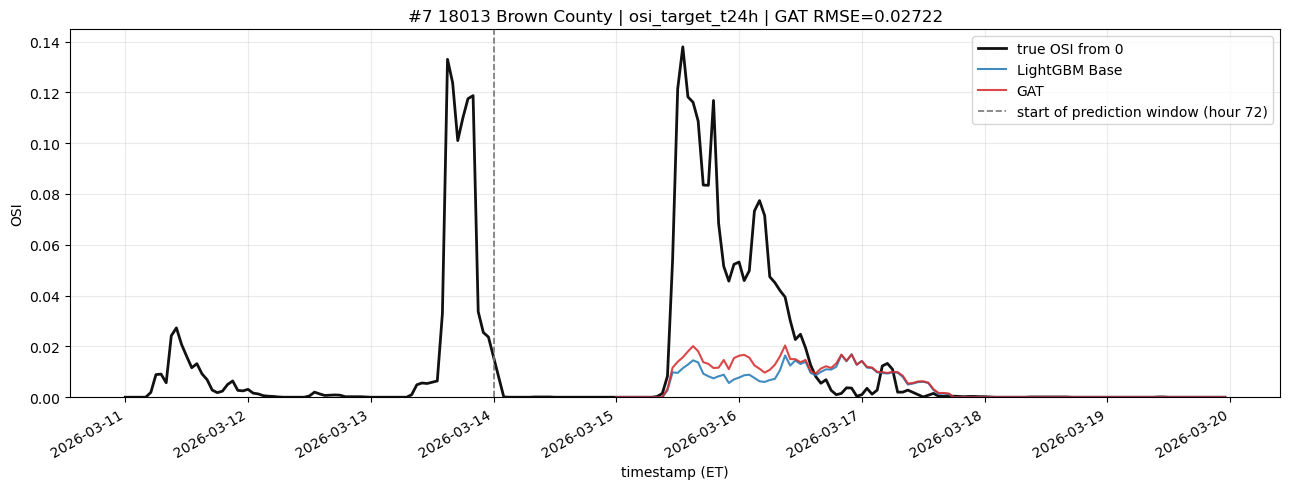

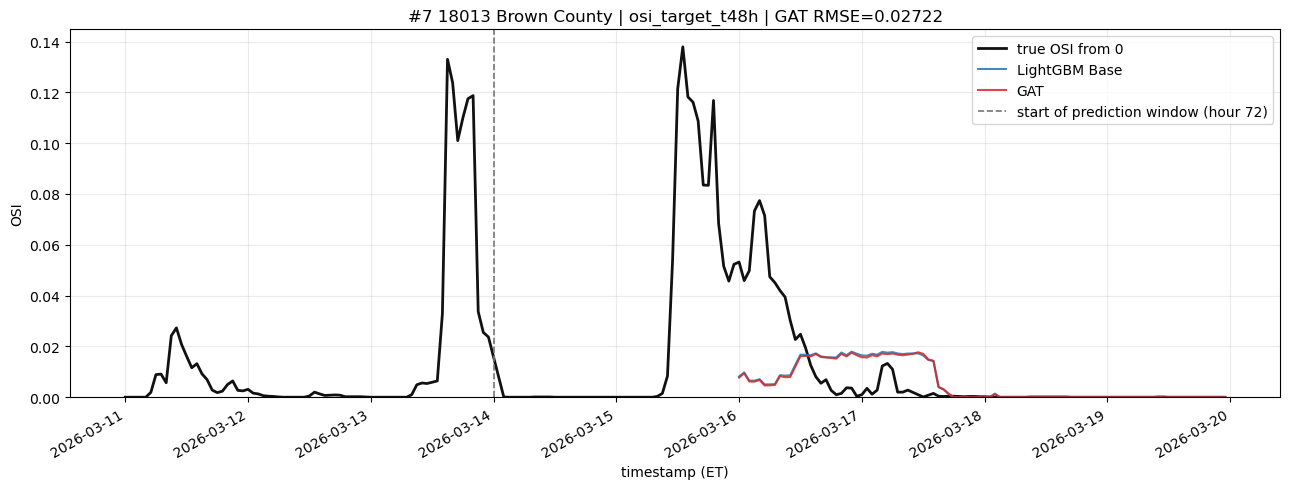

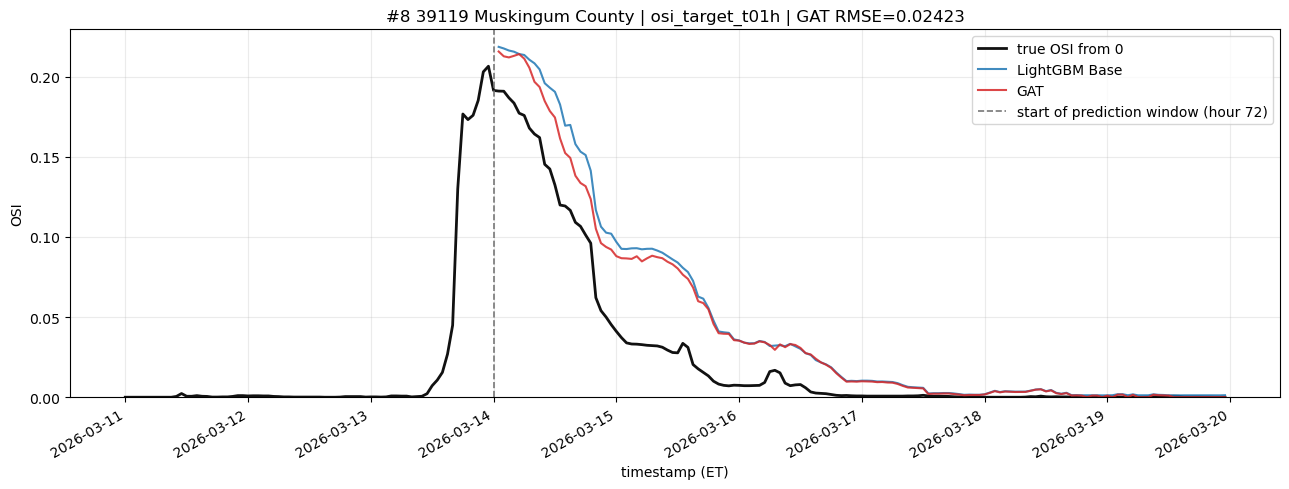

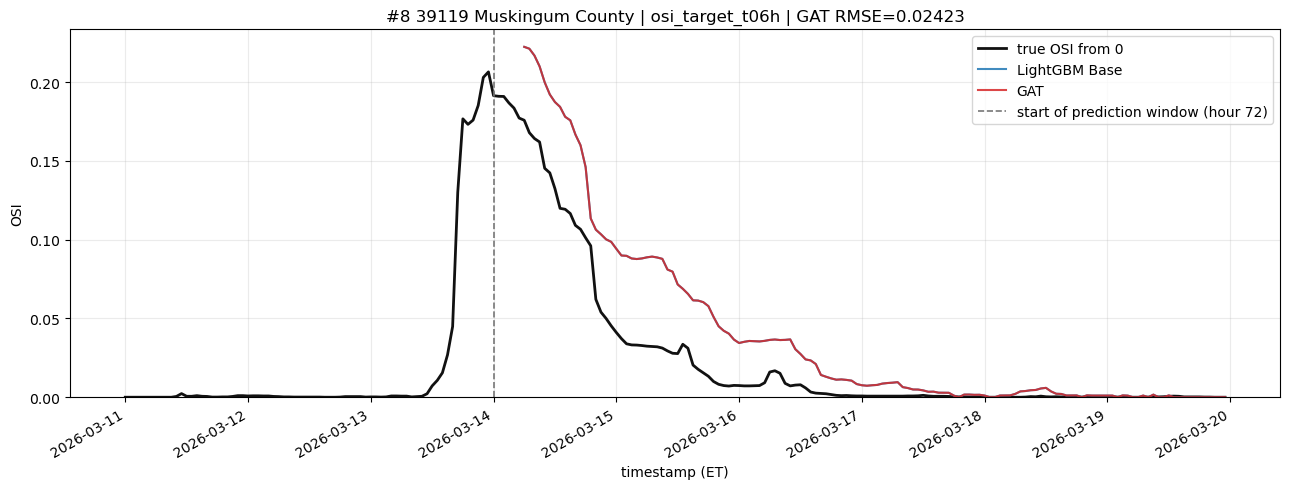

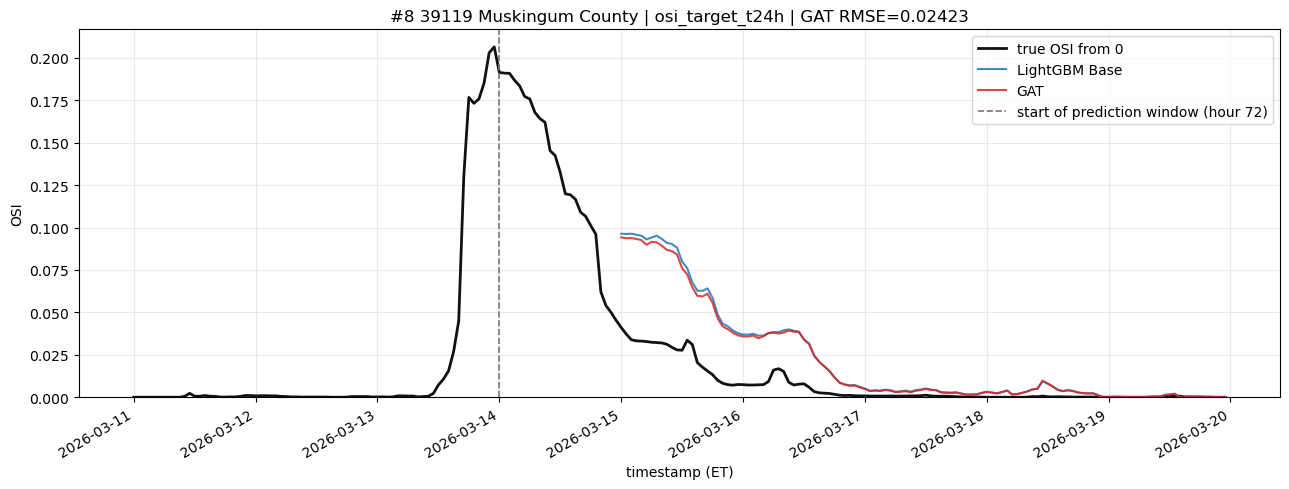

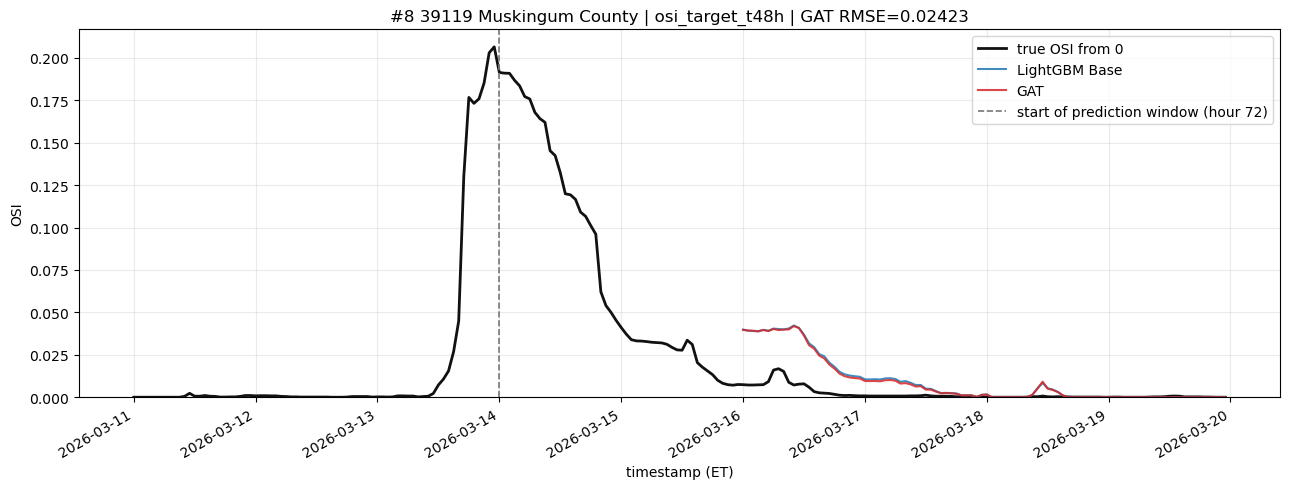

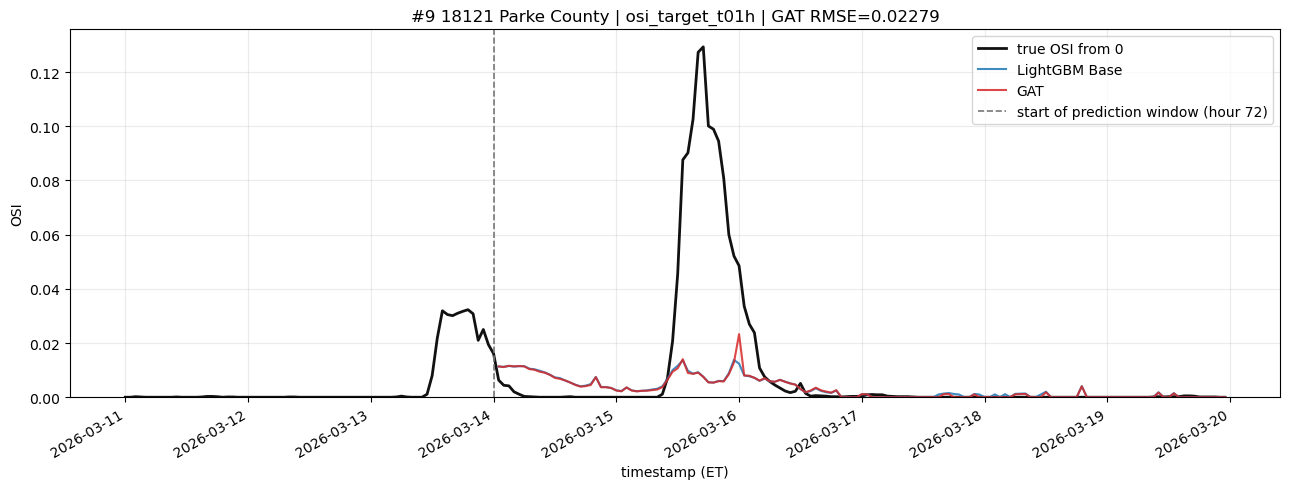

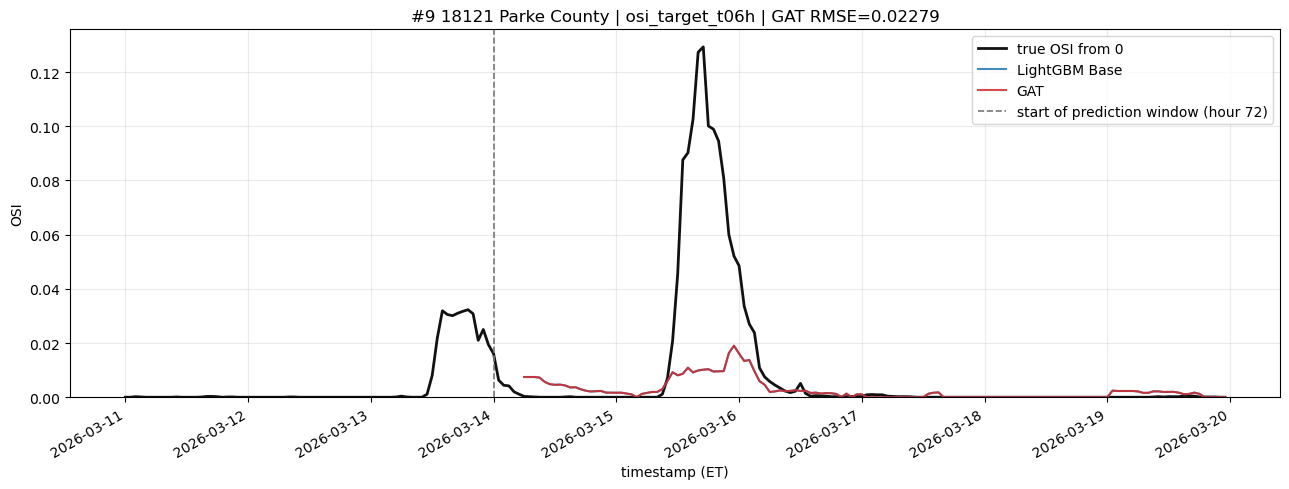

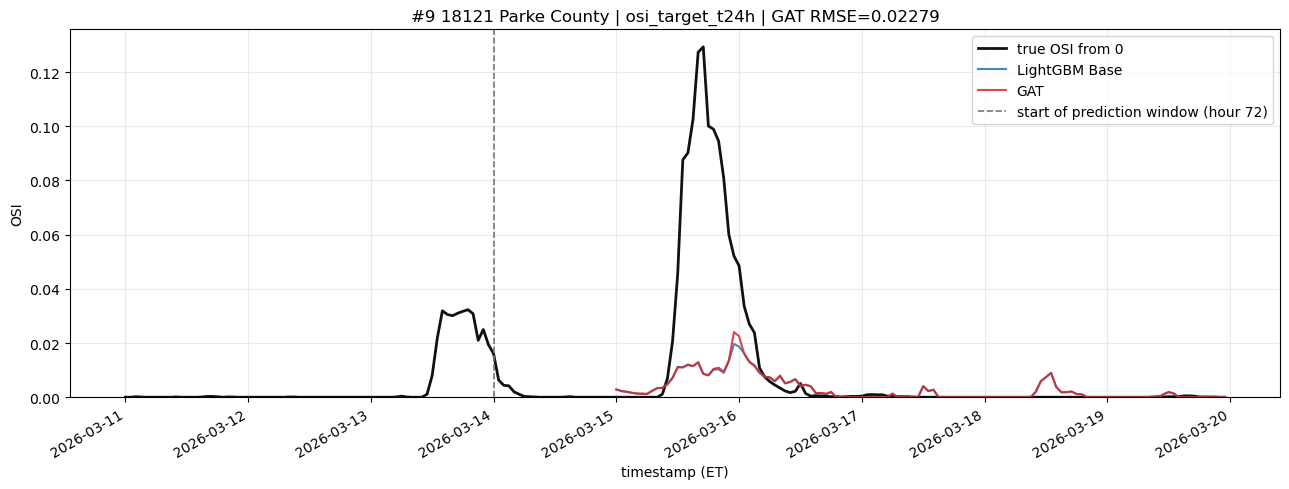

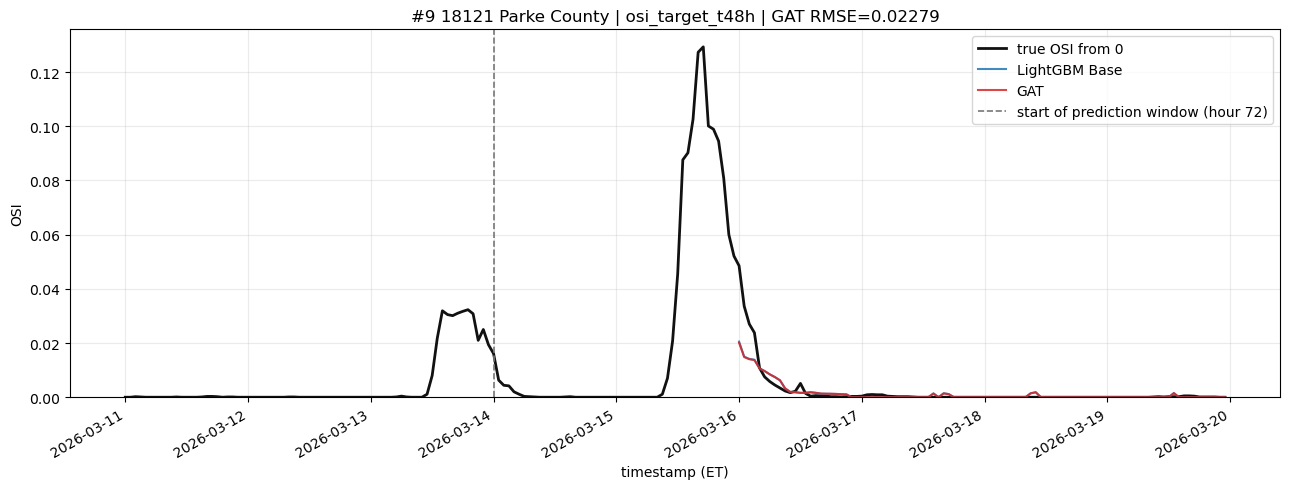

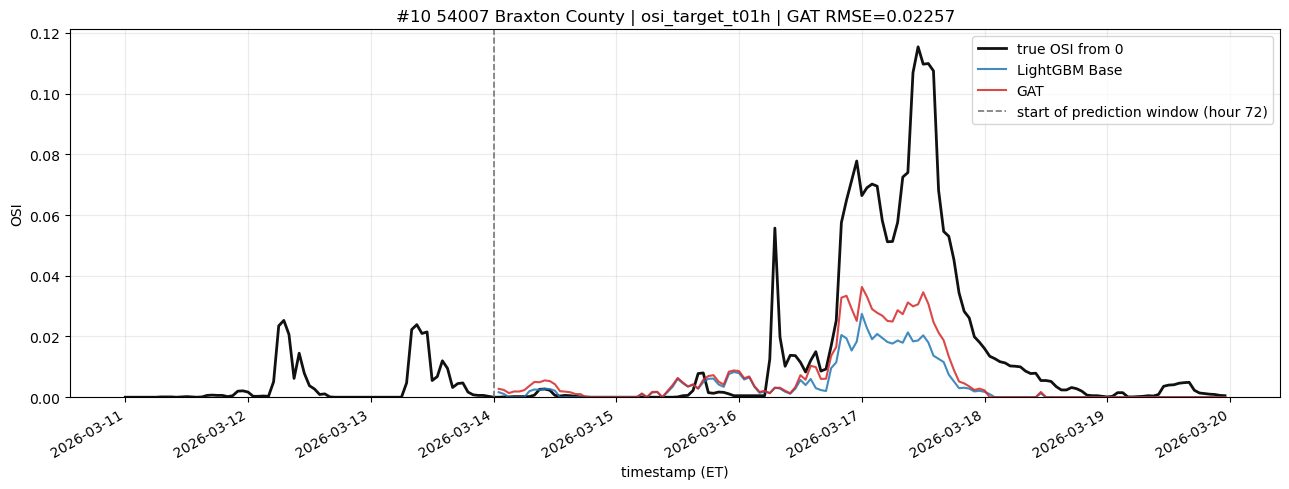

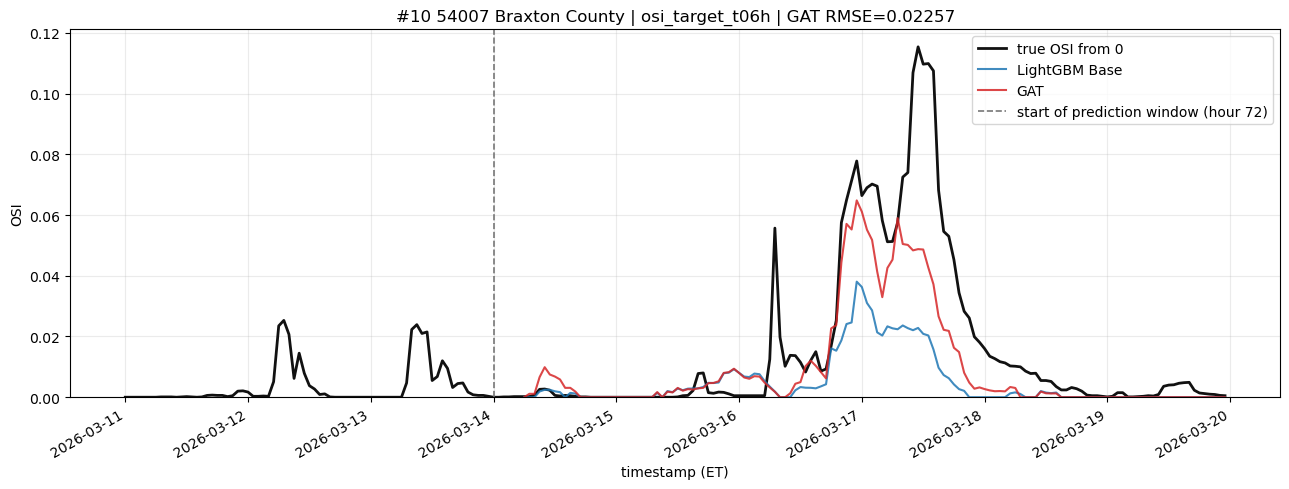

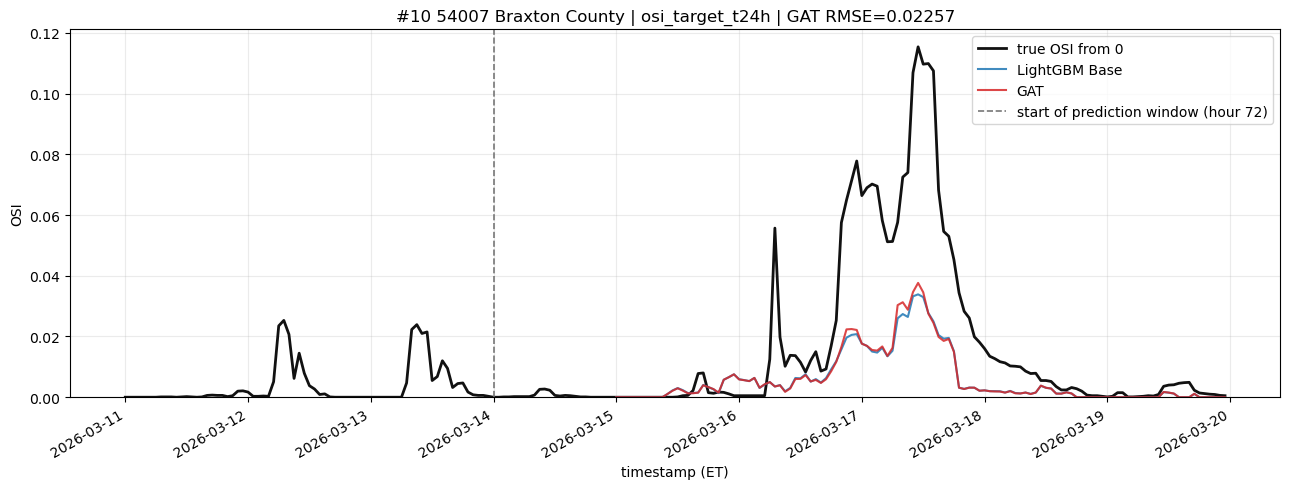

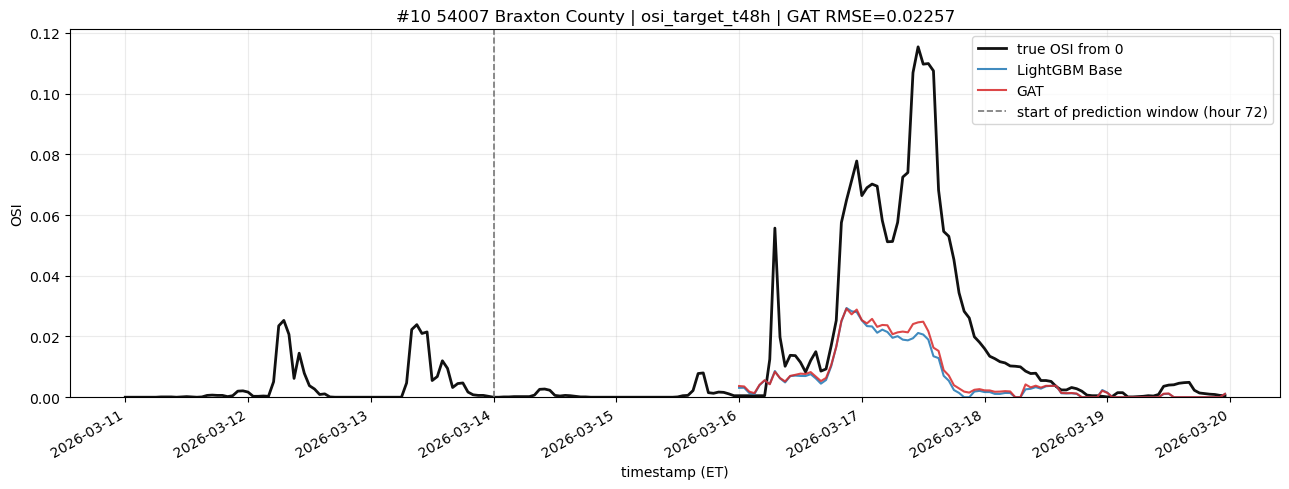

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook is diagnostic only; it does not retrain or alter the formal run.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == 'outputs' else Path(r'D:/academic/dataminingINFORMS/informs-data-mining-2026')
RUN_DIR = PROJECT_ROOT / 'code_phase2_dem_eval_v158' / 'outputs' / 'runs' / 'dem_v158_p2_component_seed42_cuda_log'
OOF_FILE = RUN_DIR / 'outer_oof.parquet'
RAW_TRAIN_FILE = PROJECT_ROOT / 'data' / 'DM_Train.csv'

HORIZONS = {
    'osi_target_t01h': 1,
    'osi_target_t06h': 6,
    'osi_target_t24h': 24,
    'osi_target_t48h': 48,
}
HORIZON_ORDER = list(HORIZONS)
PREDICTION_START_HOUR = 72
POST_START = pd.Timestamp('2026-03-11 00:00') + pd.Timedelta(hours=PREDICTION_START_HOUR)

assert OOF_FILE.exists(), OOF_FILE
assert RAW_TRAIN_FILE.exists(), RAW_TRAIN_FILE
oof = pd.read_parquet(OOF_FILE)
raw = pd.read_csv(RAW_TRAIN_FILE, dtype={'fipsCode': str})
raw['fipsCode'] = raw['fipsCode'].astype(str).str.zfill(5)
raw['timestamp_et'] = pd.to_datetime(raw['timestamp_et'], errors='raise')
raw = raw.sort_values(['fipsCode', 'timestamp_et']).reset_index(drop=True)
raw['hour_idx'] = raw.groupby('fipsCode').cumcount()

scoreable = oof.loc[oof['is_scoreable'].astype(bool)].copy()
scoreable['fipsCode'] = scoreable['fipsCode'].astype(str).str.zfill(5)
scoreable['timestamp_et'] = pd.to_datetime(scoreable['timestamp_et'], errors='raise')
scoreable['target_timestamp'] = pd.to_datetime(scoreable['target_timestamp'], errors='raise')
for col in ['y_true', 'base_prediction', 'prediction']:
    assert np.isfinite(scoreable[col].to_numpy(dtype=float)).all(), f'non-finite {col}'

county_names = (raw.sort_values(['fipsCode', 'timestamp_et'])
    .drop_duplicates('fipsCode')
    .set_index('fipsCode')['countyName'].to_dict())
state_names = (raw.sort_values(['fipsCode', 'timestamp_et'])
    .drop_duplicates('fipsCode')
    .set_index('fipsCode')['stateAbbr'].to_dict())

scoreable['base_error'] = scoreable['y_true'] - scoreable['base_prediction']
scoreable['gat_error'] = scoreable['y_true'] - scoreable['prediction']
scoreable['base_sse'] = scoreable['base_error'] ** 2
scoreable['gat_sse'] = scoreable['gat_error'] ** 2

# County ranking uses pooled GAT RMSE over all available scoreable horizons.
county_rmse = (scoreable.groupby('fipsCode', as_index=False)
    .agg(n_rows=('y_true', 'size'),
         n_horizons=('horizon', 'nunique'),
         base_sse=('base_sse', 'sum'),
         gat_sse=('gat_sse', 'sum')))
county_rmse['base_rmse'] = np.sqrt(county_rmse['base_sse'] / county_rmse['n_rows'])
county_rmse['gat_rmse'] = np.sqrt(county_rmse['gat_sse'] / county_rmse['n_rows'])
county_rmse['gat_minus_base_rmse'] = county_rmse['gat_rmse'] - county_rmse['base_rmse']
county_rmse['countyName'] = county_rmse['fipsCode'].map(county_names)
county_rmse['stateAbbr'] = county_rmse['fipsCode'].map(state_names)
county_rmse['gat_sse_contribution_pct'] = 100.0 * county_rmse['gat_sse'] / scoreable['gat_sse'].sum()
county_rmse['base_sse_contribution_pct'] = 100.0 * county_rmse['base_sse'] / scoreable['base_sse'].sum()
top10 = (county_rmse.sort_values(['gat_rmse', 'gat_sse'], ascending=False)
    .head(10).reset_index(drop=True))
top10.insert(0, 'rank', np.arange(1, len(top10) + 1))
print('scoreable rows:', len(scoreable))
print('Ranking definition: pooled GAT RMSE across all scoreable horizons')
display(top10[['rank', 'fipsCode', 'countyName', 'stateAbbr', 'n_rows', 'base_rmse', 'gat_rmse', 'gat_minus_base_rmse', 'gat_sse_contribution_pct']])

# RMSE contribution chart: county contribution to pooled squared error.
plot_top = top10.sort_values('gat_sse_contribution_pct')
y = np.arange(len(plot_top))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y + 0.18, plot_top['base_sse_contribution_pct'], height=0.34, label='Base', color='#1f77b4')
ax.barh(y - 0.18, plot_top['gat_sse_contribution_pct'], height=0.34, label='GAT', color='#d62728')
labels = plot_top['fipsCode'] + ' ' + plot_top['countyName'].fillna('')
ax.set_yticks(y, labels)
ax.set_xlabel('SSE(%)')
ax.set_title('RMSE/SSE contribution: Base 与 GAT')
ax.grid(axis='x', alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

# Optional diagnostic: top-10 county RMSE by horizon.
top_ids = set(top10['fipsCode'])
by_h = (scoreable[scoreable['fipsCode'].isin(top_ids)]
    .groupby(['fipsCode', 'horizon'], as_index=False)
    .agg(base_sse=('base_sse', 'sum'), gat_sse=('gat_sse', 'sum'), n=('y_true', 'size')))
by_h['base_rmse'] = np.sqrt(by_h['base_sse'] / by_h['n'])
by_h['gat_rmse'] = np.sqrt(by_h['gat_sse'] / by_h['n'])

# Plot the full real OSI trajectory from hour 0. Predictions begin only at the
# target timestamps available after the prediction window starts at hour 72.
for _, county_row in top10.iterrows():
    fips = county_row['fipsCode']
    name = county_row['countyName'] or ''
    truth = raw.loc[raw['fipsCode'].eq(fips)].sort_values('timestamp_et')
    pred_county = scoreable.loc[scoreable['fipsCode'].eq(fips)]
    for horizon in HORIZON_ORDER:
        part = pred_county.loc[pred_county['horizon'].eq(horizon)].sort_values('target_timestamp')
        if part.empty:
            continue
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(truth['timestamp_et'], truth['osi'], color='#111111', linewidth=2, label='true OSI from 0')
        ax.plot(part['target_timestamp'], part['base_prediction'], color='#1f77b4', alpha=0.85, label='LightGBM Base')
        ax.plot(part['target_timestamp'], part['prediction'], color='#d62728', alpha=0.85, label='GAT')
        ax.axvline(POST_START, color='#777777', linestyle='--', linewidth=1.2, label='start of prediction window (hour 72)')
        ax.set_title(f'#{int(county_row["rank"])} {fips} {name} | {horizon} | GAT RMSE={county_row["gat_rmse"]:.5f}')
        ax.set_xlabel('timestamp (ET)')
        ax.set_ylabel('OSI')
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right')
        fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()
        plt.close(fig)
